### Perform hierarchical clustering based on AUC results

In [9]:
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import numpy as np
from scipy.stats import ttest_ind, kruskal
from statsmodels.stats.multitest import multipletests
from collections import Counter
from upsetplot import UpSet, from_contents
import os
from scipy.stats import mannwhitneyu
import re

In [2]:
plots_dir = "regulon_volcano_plots/"
os.makedirs(plots_dir, exist_ok=True)

In [3]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [4]:
def regulon_diff_test(df, group_col="age_status_and_disease", comparison_groups=None):
    '''Identify regulons that change across age status and disease'''
    
    results = []
    regulons = [c for c in df.columns if c not in ["Cell_type", group_col]]

    groups = df[group_col].dropna().unique()
    
    if comparison_groups:
        comp_pairs = [comparison_groups]
    elif len(groups) == 2:
        comp_pairs = [list(groups)]
    else:
        # all pairwise comparisons
        comp_pairs = list(combinations(groups, 2))
    
    for reg in regulons:
        for g1, g2 in comp_pairs:
            sub = df[[reg, group_col]].dropna()
            vals1 = sub[sub[group_col]==g1][reg]
            vals2 = sub[sub[group_col]==g2][reg]
            
            # fold change
            mean1, mean2 = vals1.mean(), vals2.mean()
            log2fc = np.log2((mean1 + 1e-9) / (mean2 + 1e-9))
            
            # t-test
            stat, pval = mannwhitneyu(vals1, vals2, alternative='two-sided')
            
            results.append({
                "regulon": reg,
                "group1": g1,
                "group2": g2,
                "log2FC": log2fc,
                "pvalue": pval
            })
    
    res_df = pd.DataFrame(results)
    res_df["padj"] = multipletests(res_df["pvalue"], method="fdr_bh")[1]
    return res_df.sort_values("padj")

In [5]:
def plot_volcano(df, log2fc_col="log2FC", padj_col="padj", label_col="regulon",
                 fc_thresh=0.2, p_thresh=0.05, top_n=5, figsize=(8,6)):
    """
    Plot a volcano plot for differential analysis results.
    
    Parameters:
    - df: pd.DataFrame with at least log2FC and padj columns
    - log2fc_col: column name for log2 fold change
    - padj_col: column name for adjusted p-value
    - label_col: column name for labeling top hits
    - fc_thresh: fold-change threshold for significance
    - p_thresh: padj threshold for significance
    - top_n: number of top hits to label
    - figsize: matplotlib figure size
    """
    df = df.copy()
    df["neg_log10_padj"] = -np.log10(df[padj_col])
    
    # significant points
    df["sig"] = (abs(df[log2fc_col]) > fc_thresh) & (df[padj_col] < p_thresh)
    
    # assign color: red=up, blue=down, grey=ns
    df["color"] = "grey"
    df.loc[(df[log2fc_col] > fc_thresh) & (df[padj_col] < p_thresh), "color"] = "red"
    df.loc[(df[log2fc_col] < -fc_thresh) & (df[padj_col] < p_thresh), "color"] = "blue"
    
    plt.figure(figsize=figsize)
    sns.scatterplot(
        data=df,
        x=log2fc_col,
        y="neg_log10_padj",
        hue="color",
        palette={"red":"red",
                 "blue":"blue",
                 "grey":"grey"},
        edgecolor=None,
        alpha=0.7,
        legend=False
    )
    
    # threshold lines
    plt.axhline(-np.log10(p_thresh), color="black", linestyle="--", lw=1)
    plt.axvline(fc_thresh, color="black", linestyle="--", lw=1)
    plt.axvline(-fc_thresh, color="black", linestyle="--", lw=1)
    
    # annotate top hits
    sig_df = df[df["sig"]]
    for _, row in sig_df.nlargest(top_n, "neg_log10_padj").iterrows():
        plt.text(
            row[log2fc_col],
            row["neg_log10_padj"] + 0.5,
            row[label_col],
            ha="center",
            fontsize=6
        )
    
    plt.title("Volcano Plot")
    plt.xlabel("log2 Fold Change")
    plt.ylabel("-log10(padj)")
    plt.tight_layout()
    return plt

In [32]:
AUC_df = pd.read_csv("04A_regulon_AUC_df.csv", index_col = 0)

# keep only the direct (+/+)
#AUC_df = AUC_df.loc[:, AUC_df.columns.str.contains("_direct_\\+/\\+")]
#AUC_df = AUC_df.loc[:, AUC_df.columns.str.contains(r'\+/\\+')]

In [22]:
AUC_df.columns = AUC_df.columns.str.replace(r'_direct_|_\(\d+g\)', '', regex=True)

In [23]:
AUC_df

""
Cell
Cardiomyocyte:N:fetal_0
Cardiomyocyte:N:fetal_1
Cardiomyocyte:N:fetal_2
Cardiomyocyte:N:fetal_3
Cardiomyocyte:N:fetal_4
...
Pericyte:Y:postnatal_1995
Pericyte:Y:postnatal_1996
Pericyte:Y:postnatal_1997


In [7]:
# split by colon first
split_cols = AUC_df.index.to_series().str.split(":", expand=True)

# first two columns
AUC_df["Cell_type"] = split_cols[0]
AUC_df["disease"] = split_cols[1]

# take only the first part before '_' for age_status
AUC_df["age_status"] = split_cols[2].str.split("_").str[0]

AUC_df["age_status_and_disease"] = AUC_df['age_status'] + "_" +  AUC_df['disease']

In [10]:
AUC_df.columns = AUC_df.columns.str.replace(r'_direct_.*\(\d+g\)', '', regex=True)

In [16]:
AUC_df.loc[:, "AR"]

Cell
Cardiomyocyte:N:fetal_0      0.046213
Cardiomyocyte:N:fetal_1      0.020371
Cardiomyocyte:N:fetal_2      0.034913
Cardiomyocyte:N:fetal_3      0.043518
Cardiomyocyte:N:fetal_4      0.039209
                               ...   
Pericyte:Y:postnatal_1995    0.027655
Pericyte:Y:postnatal_1996    0.037781
Pericyte:Y:postnatal_1997    0.054537
Pericyte:Y:postnatal_1998    0.000480
Pericyte:Y:postnatal_1999    0.032565
Name: AR, Length: 30000, dtype: float64

In [8]:
Counter(AUC_df["age_status_and_disease"])

Counter({'fetal_N': 10000, 'postnatal_N': 10000, 'postnatal_Y': 10000})

In [9]:
cell_types = AUC_df['Cell_type'].unique()

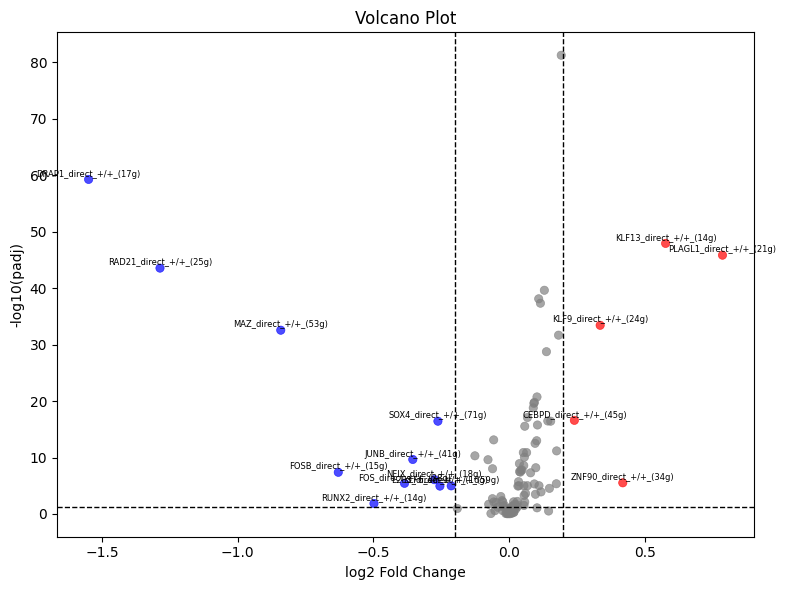

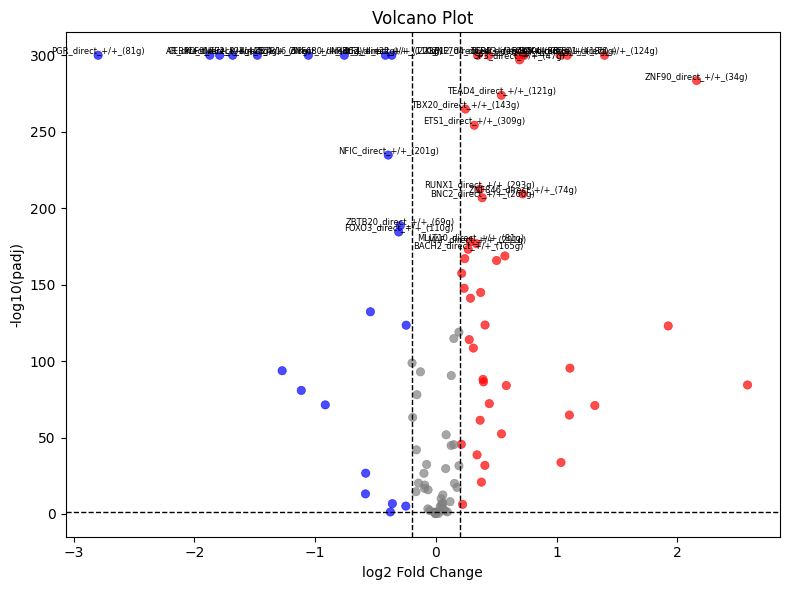

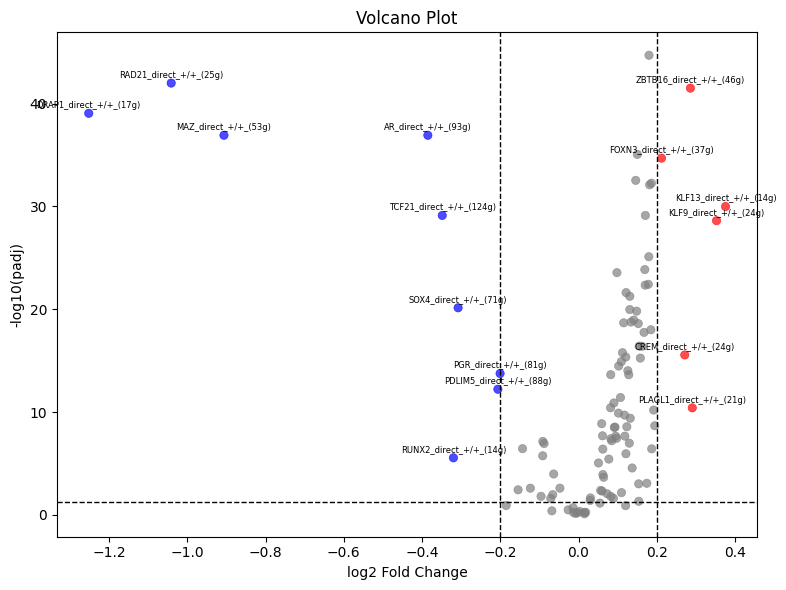

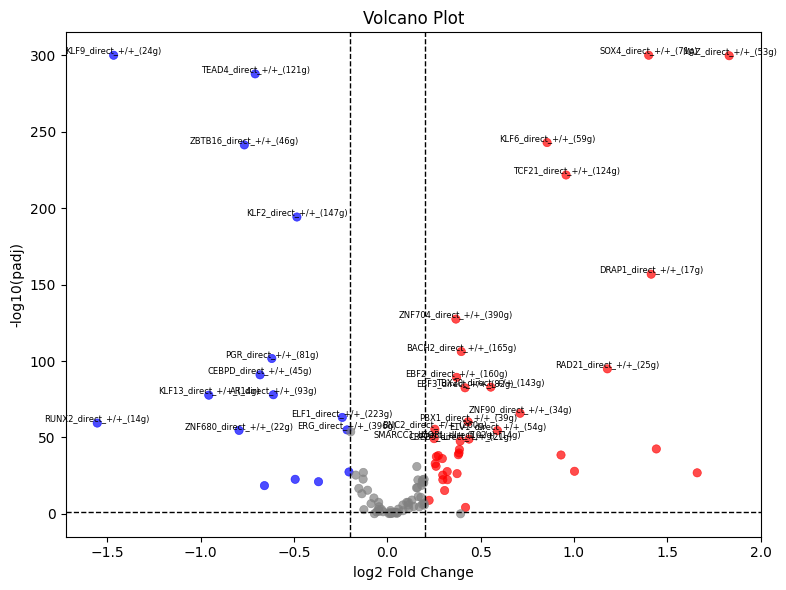

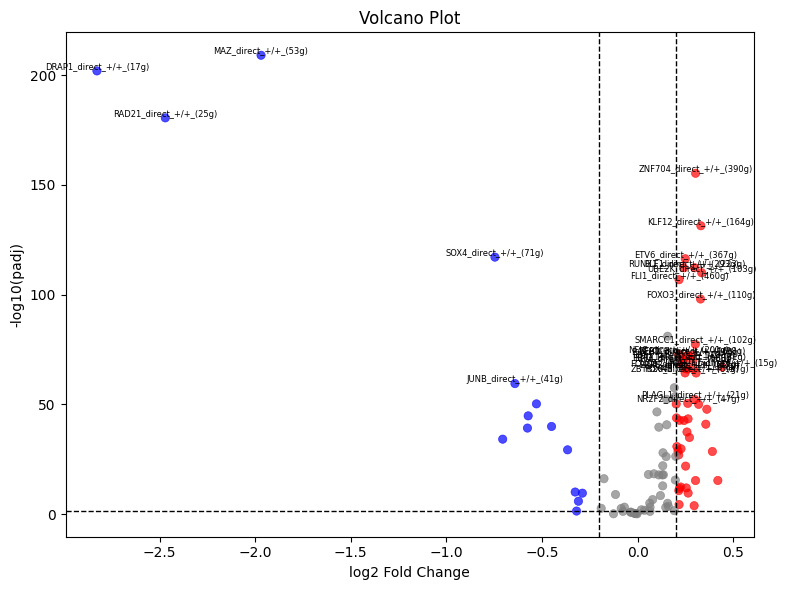

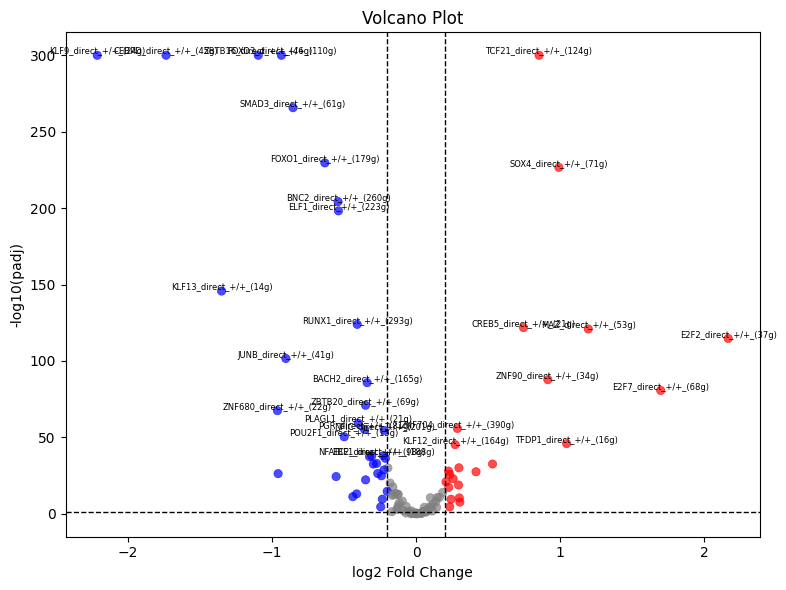

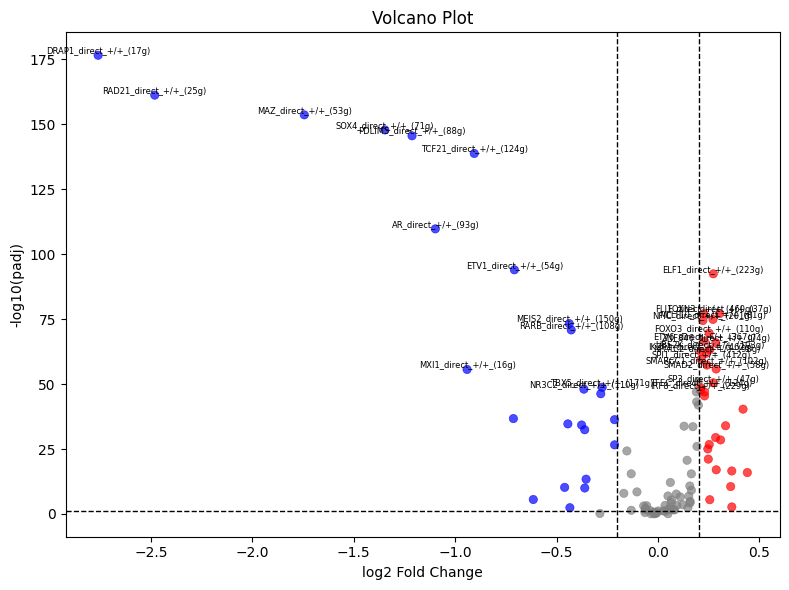

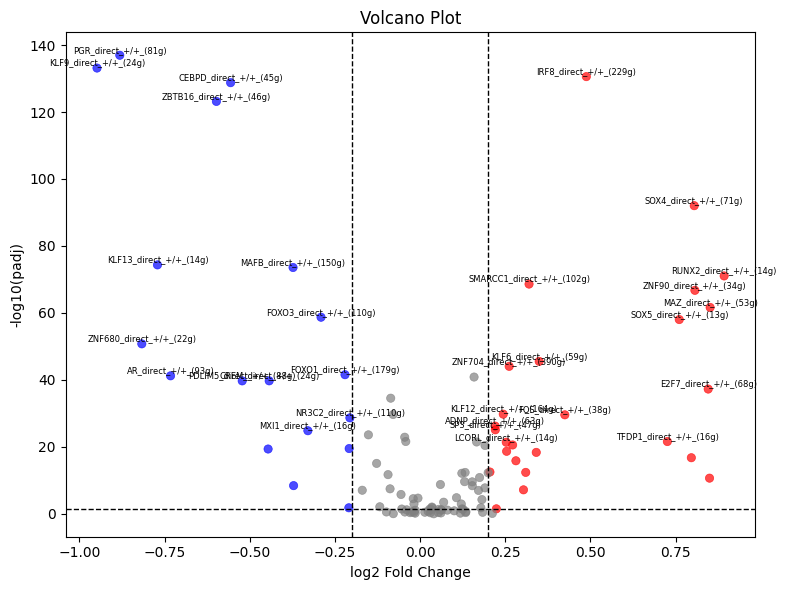

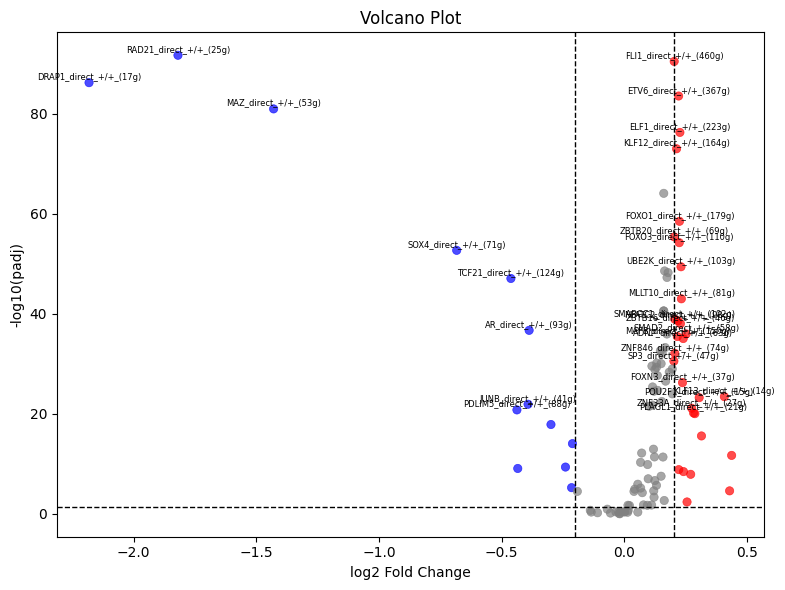

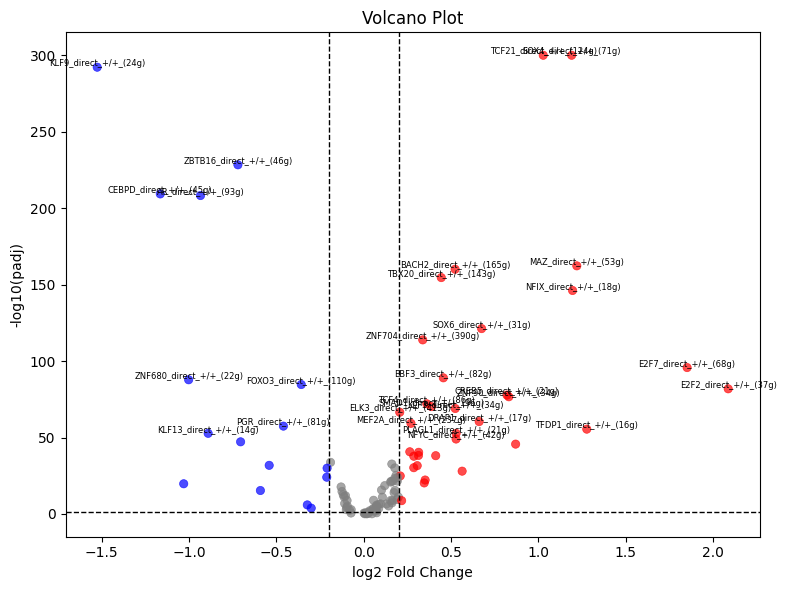

In [16]:
fetal_res_list = list()
disease_res_list = list()

for cell_type in cell_types:
    cell_type_df = AUC_df[AUC_df['Cell_type'] == cell_type]
    cell_type_df = cell_type_df.drop(columns = {"Cell_type", "disease", "age_status"})

    # disease vs. non-diseased
    res_df = regulon_diff_test(cell_type_df, group_col="age_status_and_disease", comparison_groups=["postnatal_Y", "postnatal_N"])
    res_df['padj'] = res_df['padj'] + 1e-300
    res_df['cell_type'] = cell_type
    plot_volcano(res_df, top_n = 30)
    disease_res_list.append(res_df)
    #plt.savefig("04B_CM_sex_differential_regulon_activity.pdf")

    # fetal vs. postnatal
    fetal_res_df = regulon_diff_test(cell_type_df, group_col="age_status_and_disease", comparison_groups=["fetal_N", "postnatal_N"])
    fetal_res_df['cell_type'] = cell_type
    fetal_res_df['padj'] = fetal_res_df['padj'] + 1e-300
    plot_volcano(fetal_res_df, top_n = 30)

    fetal_res_list.append(fetal_res_df)
    #plt.savefig("04B_CM_sex_differential_regulon_activity.pdf")

    # identify TFs intersecting
    fetal_up = fetal_res_df[fetal_res_df['log2FC'] > 0.25]
    disease_up = res_df[res_df['log2FC'] > 0.25]
    
    # examine GRN sets
    #disease_up = res_df[res_df['log2FC'] > 0.25]
    #disease_down = res_df[res_df['log2FC'] < -0.25]
    #fetal_up = fetal_res_df[fetal_res_df['log2FC'] > 0.25]
    #fetal_down = fetal_res_df[fetal_res_df['log2FC'] < -0.25]

    #sets = {
    #    'disease_up': set(disease_up['regulon']),
    #    'disease_down': set(disease_down['regulon']),
    #    'fetal_up': set(fetal_up['regulon']),
    #    'fetal_down': set(fetal_down['regulon'])
    #}

    #upset_data = from_contents(sets)
    #UpSet(upset_data, subset_size='count', show_counts=True).plot()
    #plt.title("Overlap of TF regulons: disease vs fetal (up/down)")

In [17]:
fetal_combined_df = pd.concat(fetal_res_list)
fetal_combined_df.to_csv("04B_fetal_sig_regulon_df.csv")

In [18]:
disease_combined_df = pd.concat(disease_res_list)
disease_combined_df.to_csv("04B_disease_sig_regulon_df.csv")